<a href="https://colab.research.google.com/github/440g/painkiller/blob/After_Datacleaning/After_Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/440g/painkiller.git

Cloning into 'painkiller'...
remote: Enumerating objects: 387, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 387 (delta 27), reused 22 (delta 11), pack-reused 329 (from 1)
Receiving objects: 100% (387/387), 30.21 MiB | 21.54 MiB/s, done.
Resolving deltas: 100% (112/112), done.


In [ ]:
%cd /content/painkiller/src

/content/painkiller/src


In [ ]:
import os
os.makedirs('../datasets', exist_ok=True)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
X_train_re=pd.read_csv('../datasets/preprocessed/X_train.csv')
y_train_re=pd.read_csv('../datasets/preprocessed/y_train.csv')
X_train_val_re=pd.read_csv('../datasets/preprocessed/X_val.csv')
y_train_val_re=pd.read_csv('../datasets/preprocessed/y_val.csv')

In [2]:
import sklearn
from sklearn.preprocessing import StandardScaler

# 범주형인데 숫자로 맵핑된 변수 제외 스케일링
num_cols = [col for col in X_train_re.columns if col not in ['data_channel', 'weekday']]
# 숫자형만 스케일링
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_re[num_cols])
X_val_num_scaled = scaler.transform(X_train_val_re[num_cols])

# DataFrame으로 변환
X_train_num_scaled_df = pd.DataFrame(X_train_num_scaled, columns=num_cols, index=X_train_re.index)
X_val_num_scaled_df = pd.DataFrame(X_val_num_scaled, columns=num_cols, index=X_train_val_re.index)

# 제외한 범주형 변수는 그대로 붙임
X_train_scaled_df = pd.concat([X_train_num_scaled_df, X_train_re[['data_channel', 'weekday']]], axis=1)
X_val_scaled_df = pd.concat([X_val_num_scaled_df, X_train_val_re[['data_channel', 'weekday']]], axis=1)


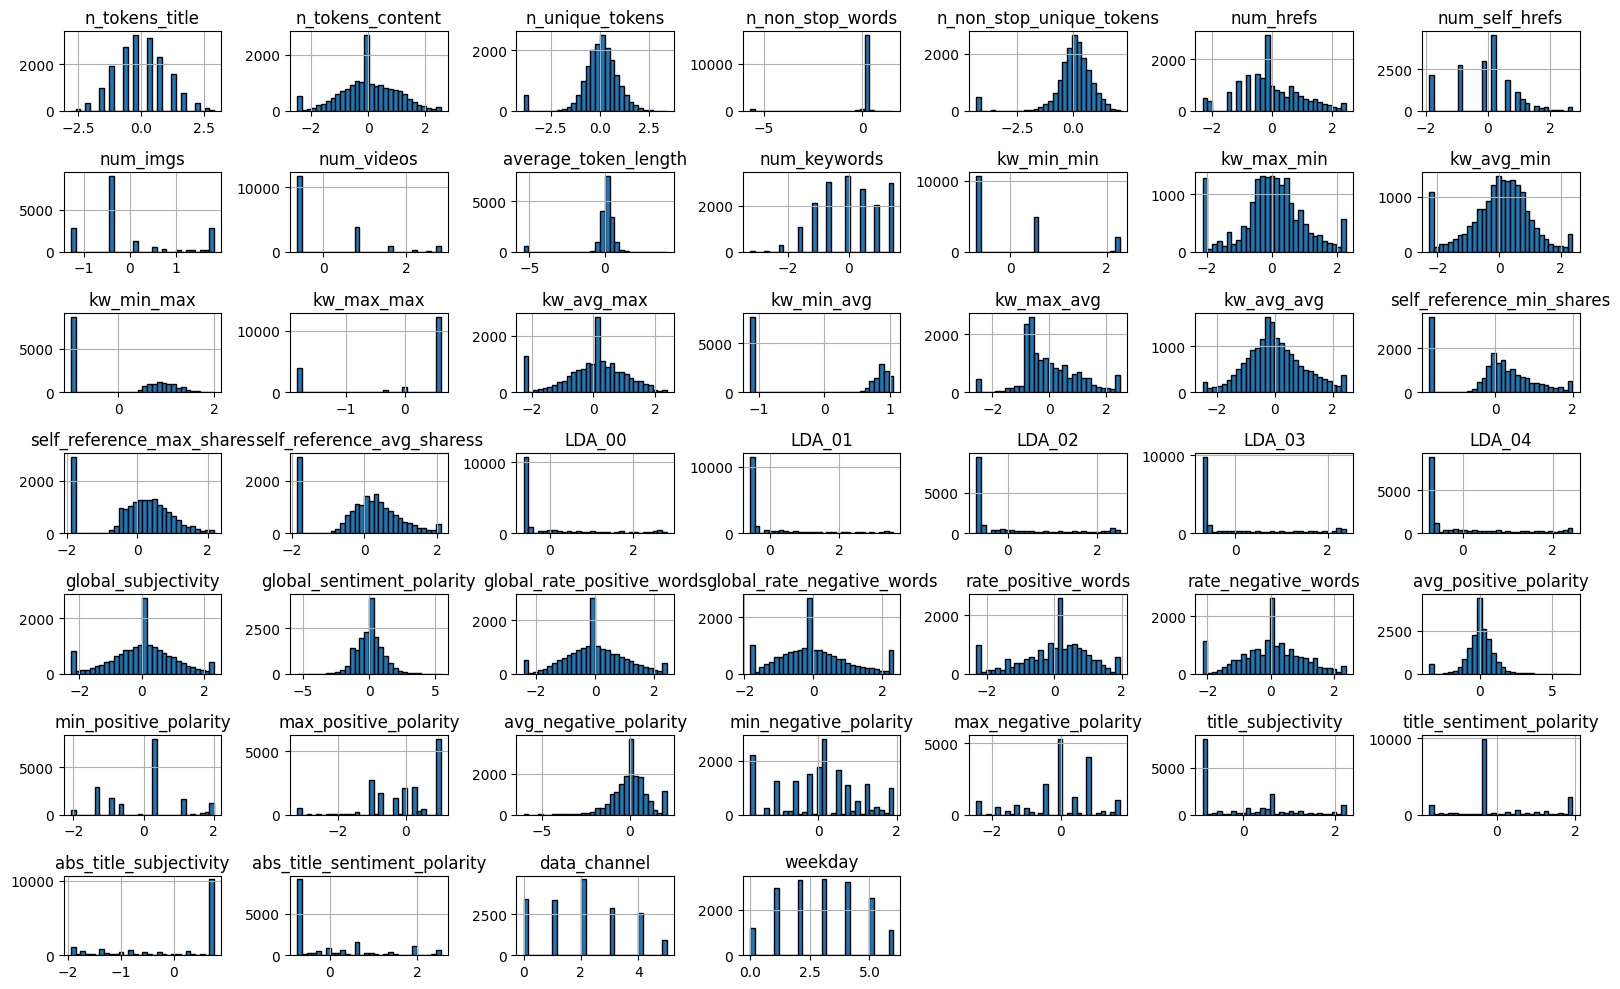

In [3]:
import matplotlib.pyplot as plt
#스케일링 결과 확인
X_train_scaled_df.hist(bins=30, figsize=(16, 10), edgecolor='black')
plt.tight_layout()
plt.show()

In [4]:
X_train=X_train_scaled_df
y_train=y_train_re
X_val=X_val_scaled_df
y_val=y_train_val_re

#feature 정리

In [5]:
#SelectKBest(f_classif)에 따른 feature 중요도 판단
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# feature 선택 (전체 feature에 대해 f값과 p값 구함)
selector = SelectKBest(score_func=f_classif, k='all')  # 전부 평가
selector.fit(X_train_scaled_df, y_train_re)

# f 점수와 p값 추출
f_scores = selector.scores_
p_values = selector.pvalues_
feature_names = X_train_scaled_df.columns

# 시리즈로 정리
f_scores_series = pd.Series(f_scores, index=feature_names).sort_values(ascending=False)
p_values_series = pd.Series(p_values, index=feature_names)

# f-score 기준 하위 10개 feature 추출
low_f_features = f_scores_series.sort_values().head(10)
print("f-score 하위 10개 feature:")
print(low_f_features)

#하위 10개 이름 추출해서 p-value도 함께 출력
low_f_feature_names = low_f_features.index.tolist()
for feat in low_f_feature_names:
    print(f"{feat}: f = {f_scores_series[feat]:.3f}, p = {p_values_series[feat]:.4e}")

f-score 하위 10개 feature:
min_negative_polarity      0.028461
kw_avg_max                 0.028635
avg_negative_polarity      0.071366
abs_title_subjectivity     0.091947
max_negative_polarity      0.270302
avg_positive_polarity      2.807930
n_tokens_content           2.835716
kw_min_max                 3.303052
kw_min_avg                 3.524551
n_non_stop_words          10.227249
dtype: float64
min_negative_polarity: f = 0.028, p = 8.6603e-01
kw_avg_max: f = 0.029, p = 8.6563e-01
avg_negative_polarity: f = 0.071, p = 7.8936e-01
abs_title_subjectivity: f = 0.092, p = 7.6172e-01
max_negative_polarity: f = 0.270, p = 6.0314e-01
avg_positive_polarity: f = 2.808, p = 9.3817e-02
n_tokens_content: f = 2.836, p = 9.2207e-02
kw_min_max: f = 3.303, p = 6.9168e-02
kw_min_avg: f = 3.525, p = 6.0483e-02
n_non_stop_words: f = 10.227, p = 1.3862e-03


/Users/minseokim/miniconda/envs/kaggle/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


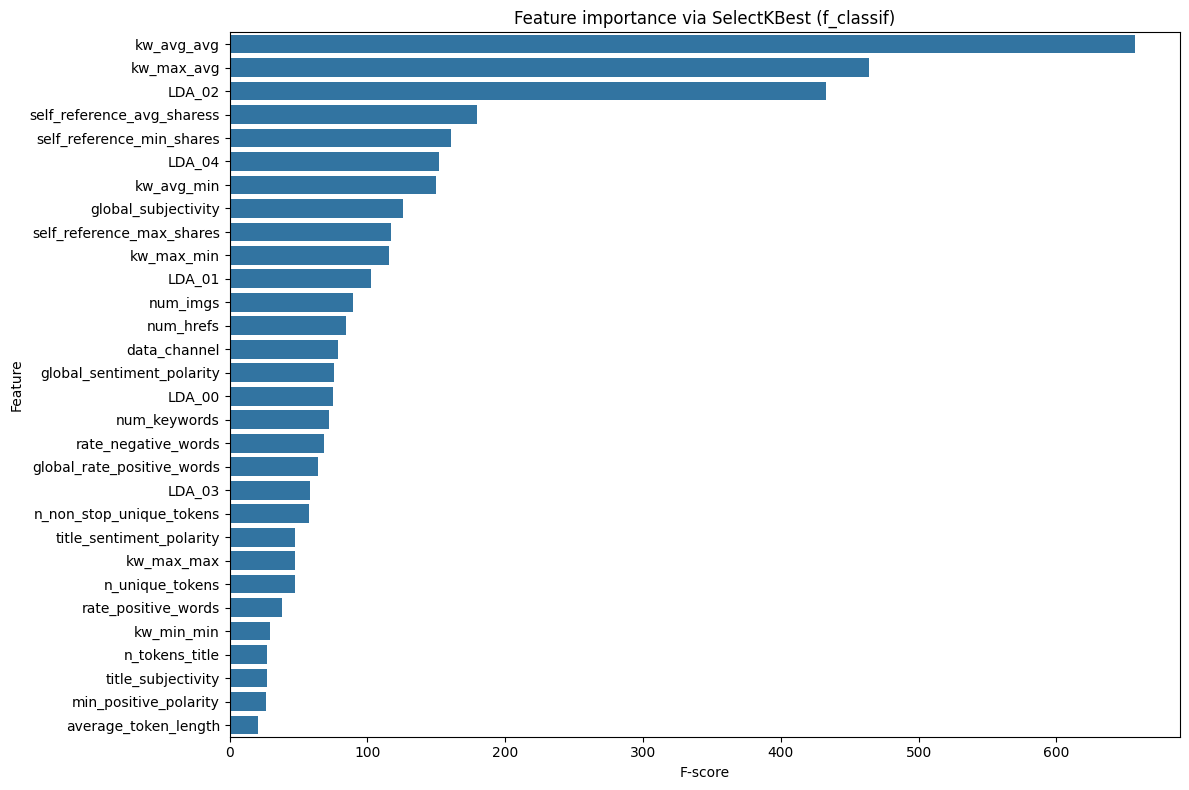

'# p값\nsignificant_features = p_values_series[p_values_series < 0.05].index.tolist()\nprint("p < 0.05로 유의미한 피처:", significant_features)'

In [6]:
#SelectKBest(f_classif)에 따른 feature 중요도 시각화 (f 점수 높은 순)
plt.figure(figsize=(12, 8))
sns.barplot(x=f_scores_series.values[:30], y=f_scores_series.index[:30])  # 상위 30개만 표시
plt.title("Feature importance via SelectKBest (f_classif)")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

'''# p값
significant_features = p_values_series[p_values_series < 0.05].index.tolist()
print("p < 0.05로 유의미한 피처:", significant_features)'''

In [7]:
#target값과 각 feature 간의 상관관계에 따른 feature 중요도 판단
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# y를 포함한 새로운 데이터프레임 생성
df_corr = X_train_scaled_df.copy()
df_corr['target'] = y_train_re.values  # 같은 index

# 상관계수 계산
target_corr = df_corr.corr()['target'].drop('target').sort_values(key=np.abs, ascending=False)
# 상관계수 절댓값 기준으로 오름차순 정렬, 하위 10개
low_corr_with_target = target_corr.abs().sort_values().head(10)

print("타겟과 상관관계 약한 하위 10개 피처:")
print(low_corr_with_target)

타겟과 상관관계 약한 하위 10개 피처:
min_negative_polarity     0.001266
kw_avg_max                0.001270
avg_negative_polarity     0.002005
abs_title_subjectivity    0.002276
max_negative_polarity     0.003903
avg_positive_polarity     0.012578
n_tokens_content          0.012640
kw_min_max                0.013642
kw_min_avg                0.014092
n_non_stop_words          0.024000
Name: target, dtype: float64


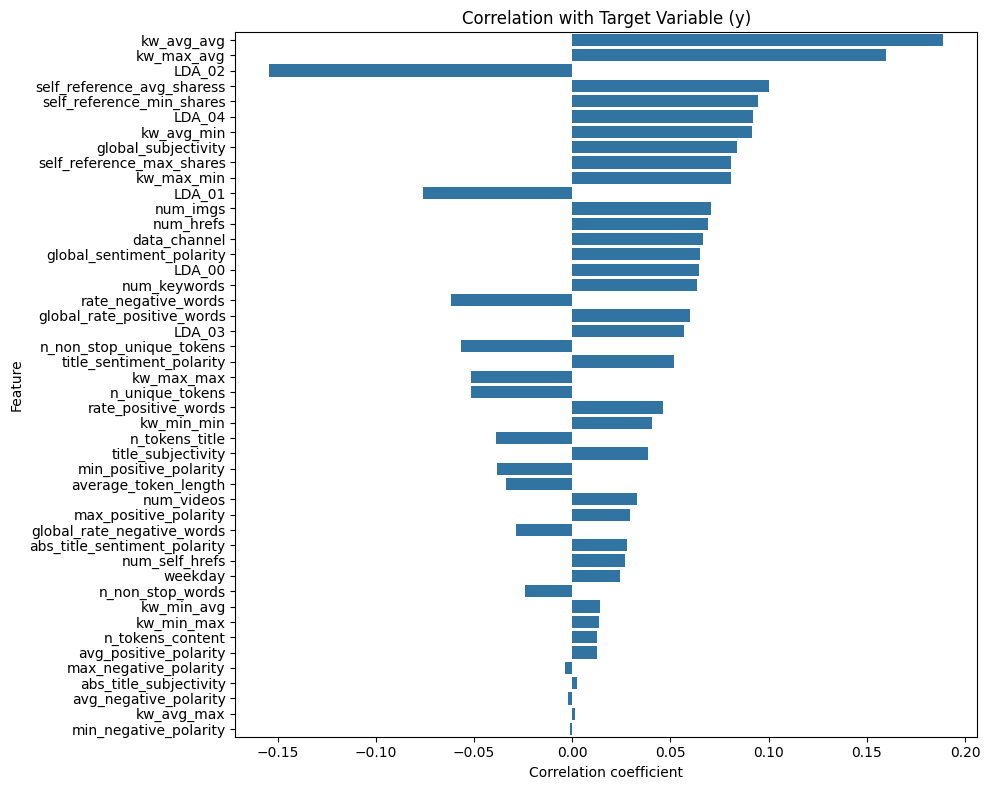

In [8]:
# target값과 각 feature 간의 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title('Correlation with Target Variable (y)')
plt.xlabel('Correlation coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [9]:
#모델 기반 feature 중요도 판단(랜덤 포레스트 기준)
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 스케일된 train 데이터 기준으로 모델 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled_df, y_train_re)

# 2. feature 중요도 추출
importances = pd.Series(rf.feature_importances_, index=X_train_scaled_df.columns)

# 중요도 기준 하위 10개 feature 추출
low_10_features = importances.sort_values().head(10)
print(low_10_features)

/Users/minseokim/miniconda/envs/kaggle/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


kw_max_max                  0.006142
num_videos                  0.006752
kw_min_min                  0.008616
num_imgs                    0.010937
num_keywords                0.011263
abs_title_subjectivity      0.011325
min_positive_polarity       0.011337
title_sentiment_polarity    0.011600
max_positive_polarity       0.011892
n_non_stop_words            0.012135
dtype: float64


In [10]:
#각 기준별 하위 10개 피처 종합
#랜덤포레스트
low_10_features = importances.sort_values().head(10)
#타겟과의 상관계수
low_corr_with_target = target_corr.abs().sort_values().head(10)
#f-score와 p-value 기반
low_f_features = f_scores_series.sort_values().head(10)

In [11]:
#위의 세 기준에 따른 하위 10개 중 공통된 feature 찾기
# 리스트 변환
low_rf_names = low_10_features.index.tolist()
low_corr_names = low_corr_with_target.index.tolist()

# 공통된 feature
common_low_features = list(set(low_rf_names) & set(low_corr_names) & set(low_f_feature_names))
#common_low_features = list(set(low_f_feature_names) & set(low_corr_names))

print("모든 기준에서 중요도 하위 10에 속하는 feature (3중 교집합):")
print(common_low_features)

모든 기준에서 중요도 하위 10에 속하는 feature (3중 교집합):
['abs_title_subjectivity', 'n_non_stop_words']


In [12]:
features_to_drop = ['abs_title_subjectivity', 'num_videos']
#중요도 떨어지는 변수 드랍 후 다시 저장
X_train_re2 = X_train.drop(columns=features_to_drop)
X_train_val_re2 = X_val.drop(columns=features_to_drop)
y_train_re2 = y_train.copy()
y_train_val_re2 = y_val.copy()

X_train_re2.to_csv('../datasets/preprocessed/X_train2.csv', index=False)
y_train_re2.to_csv('../datasets/preprocessed/y_train2.csv', index=False)

X_train_val_re2.to_csv('../datasets/preprocessed/X_val2.csv', index=False)
y_train_val_re2.to_csv('../datasets/preprocessed/y_val2.csv', index=False)


In [13]:
X_test1 = pd.read_csv('../datasets/preprocessed/X_test.csv')
# trainset에 대해 적용한 그대로 스케일링
X_test_num = X_test1[num_cols]
X_test_num_scaled = scaler.transform(X_test_num)
X_test_num_scaled_df = pd.DataFrame(X_test_num_scaled, columns=num_cols, index=X_test1.index)
X_test_scaled_df = pd.concat([X_test_num_scaled_df, X_test1[['data_channel', 'weekday']]], axis=1)

X_test2 =X_test_scaled_df
#feature드랍
X_test_re = X_test2.drop(columns=features_to_drop)

X_train_re.to_csv('../datasets/preprocessed/X_test2.csv', index=False)